In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


Importing libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

try:
    import missingno as msno
    HAS_MISSINGNO = True
except ImportError:
    HAS_MISSINGNO = False
    print("missingno not available, will fall back to a plain bar chart for missing-value visuals.")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

**Loading Dataset**

In [3]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [4]:
df = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")  # adjust if your printed path differs
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


 **Step 1: Initial Data Exploration**

In [5]:
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (891, 12)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [9]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


**Step 2: Handling Missing Values and Outliers (given)**

**2b.Visualizing missing data**

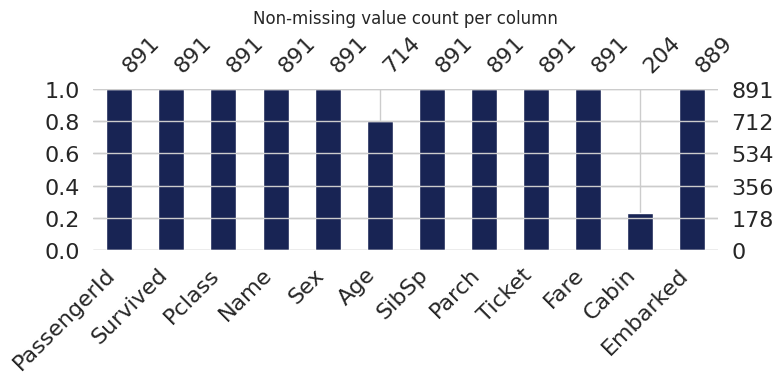

In [11]:
if HAS_MISSINGNO:
    msno.bar(df, figsize=(8, 4), color="#182454")
    plt.title("Non-missing value count per column")
    plt.tight_layout()
    plt.show()
else:
    missing_counts = df.isnull().sum().sort_values(ascending=False)
    missing_counts = missing_counts[missing_counts > 0]
    plt.figure(figsize=(6, 4))
    missing_counts.plot(kind="bar", color="#F09024")
    plt.title("Missing value count per column")
    plt.ylabel("Missing count")
    plt.tight_layout()
    plt.show()

In [12]:
missing_summary = df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)
missing_pct = (missing_summary / len(df) * 100).round(1)
pd.DataFrame({"missing_count": missing_summary, "missing_pct": missing_pct})

,missing_count,missing_pct
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2


**2b. Deciding a strategy per column**

In [13]:
df["Age_missing"] = df["Age"].isnull().astype(int)
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Has_Cabin"] = df["Cabin"].notnull().astype(int)

embarked_mode = df["Embarked"].mode()[0]
df["Embarked"] = df["Embarked"].fillna(embarked_mode)

print("Remaining missing values after cleaning:")
print(df[["Age", "Cabin", "Embarked"]].isnull().sum())
print(f"\nMost common embarkation port used to fill gaps: {embarked_mode}")

Remaining missing values after cleaning:
Age           0
Cabin       687
Embarked      0
dtype: int64

Most common embarkation port used to fill gaps: S


**2c. Detecting outliers: IQR method**

In [14]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

fare_outliers_iqr = df[(df["Fare"] < lower_bound) | (df["Fare"] > upper_bound)]
print(f"Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Fare outliers found by IQR: {len(fare_outliers_iqr)} out of {len(df)} rows")
fare_outliers_iqr[["PassengerId", "Pclass", "Fare"]].sort_values("Fare", ascending=False).head()

Q1=7.91, Q3=31.00, IQR=23.09
Bounds: [-26.72, 65.63]
Fare outliers found by IQR: 116 out of 891 rows


,PassengerId,Pclass,Fare
258,259,1,512.3292
737,738,1,512.3292
679,680,1,512.3292
27,28,1,263.0000
341,342,1,263.0000


**2d. Detecting outliers: Z-score method**

In [15]:
df["Age_zscore"] = stats.zscore(df["Age"])
age_outliers_z = df[df["Age_zscore"].abs() > 3]
print(f"Age outliers found by Z-score (|z| > 3): {len(age_outliers_z)} out of {len(df)} rows")
age_outliers_z[["PassengerId", "Age", "Age_zscore"]].sort_values("Age", ascending=False)

Age outliers found by Z-score (|z| > 3): 7 out of 891 rows


,PassengerId,Age,Age_zscore
630,631,80.0,3.891554
851,852,74.0,3.430455
96,97,71.0,3.199906
493,494,71.0,3.199906
116,117,70.5,3.161481
672,673,70.0,3.123056
745,746,70.0,3.123056


**2e. Capping outliers with winsorizing**

In [16]:
from scipy.stats.mstats import winsorize

df["Fare_winsorized"] = winsorize(df["Fare"], limits=[0.05, 0.05])
df[["Fare", "Fare_winsorized"]].describe()

,Fare,Fare_winsorized
count,891.000000,891.000000
mean,32.204208,27.917966
std,49.693429,29.288440
min,0.000000,7.225000
25%,7.910400,7.910400
50%,14.454200,14.454200
75%,31.000000,31.000000
max,512.329200,113.275000


**Step 3: Univariate Analysis (given)**

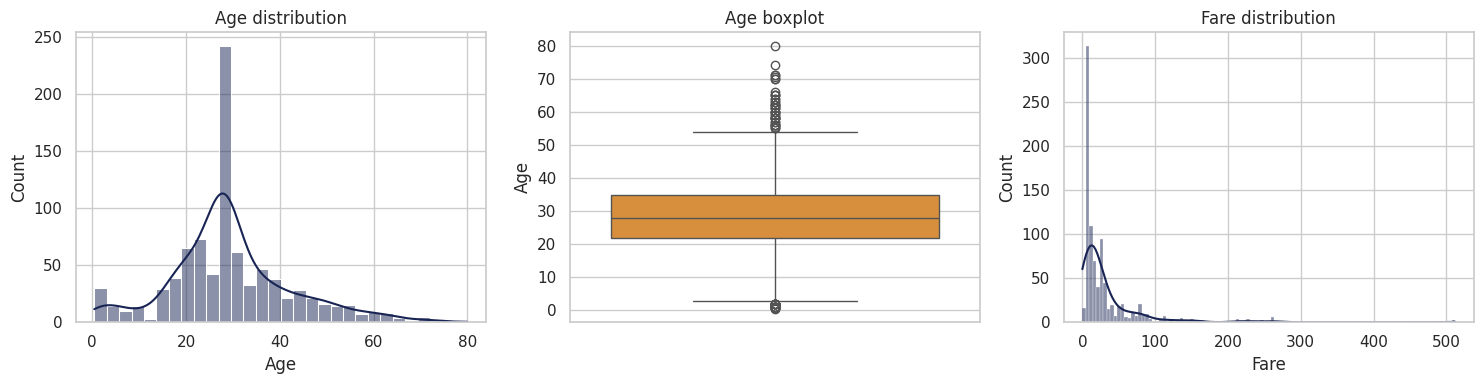

Age: mean=29.4, median=28.0, skew=0.51
Fare: mean=32.2, median=14.5, skew=4.79


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df["Age"], kde=True, ax=axes[0], color="#182454")
axes[0].set_title("Age distribution")

sns.boxplot(y=df["Age"], ax=axes[1], color="#F09024")
axes[1].set_title("Age boxplot")

sns.histplot(df["Fare"], kde=True, ax=axes[2], color="#182454")
axes[2].set_title("Fare distribution")

plt.tight_layout()
plt.show()

print(f"Age: mean={df['Age'].mean():.1f}, median={df['Age'].median():.1f}, skew={df['Age'].skew():.2f}")
print(f"Fare: mean={df['Fare'].mean():.1f}, median={df['Fare'].median():.1f}, skew={df['Fare'].skew():.2f}")

/tmp/ipykernel_58/740380968.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Sex", data=df, ax=axes[0], palette=["#182454", "#F09024"])
/tmp/ipykernel_58/740380968.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Pclass", data=df, ax=axes[1], palette="Blues_d")
/tmp/ipykernel_58/740380968.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Embarked", data=df, ax=axes[2], palette="Oranges_d")


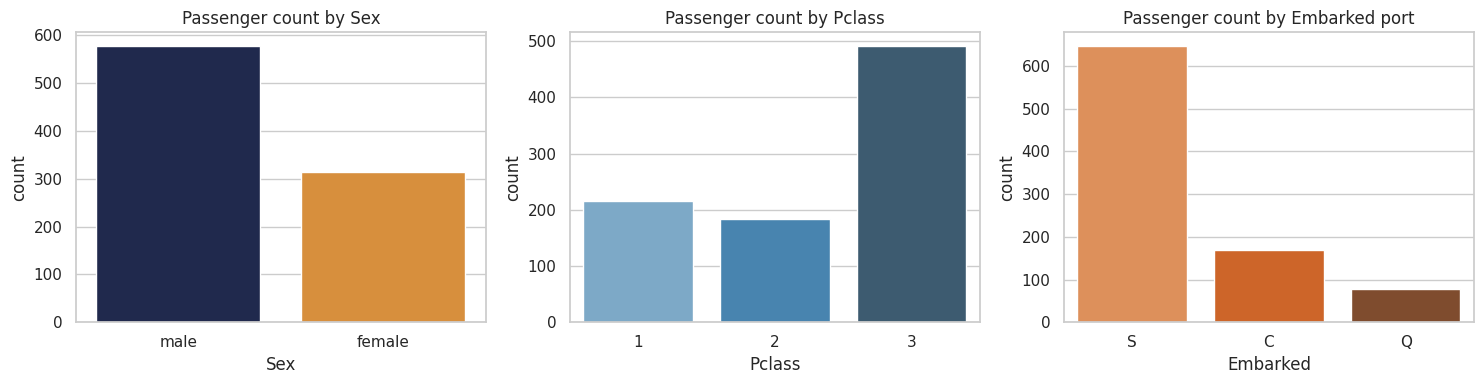

Sex
male      577
female    314
Name: count, dtype: int64 

Pclass
1    216
2    184
3    491
Name: count, dtype: int64 

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(x="Sex", data=df, ax=axes[0], palette=["#182454", "#F09024"])
axes[0].set_title("Passenger count by Sex")

sns.countplot(x="Pclass", data=df, ax=axes[1], palette="Blues_d")
axes[1].set_title("Passenger count by Pclass")

sns.countplot(x="Embarked", data=df, ax=axes[2], palette="Oranges_d")
axes[2].set_title("Passenger count by Embarked port")

plt.tight_layout()
plt.show()

print(df["Sex"].value_counts(), "\n")
print(df["Pclass"].value_counts().sort_index(), "\n")
print(df["Embarked"].value_counts())

**Step 4: Bivariate Analysis (your work)**

**Numerical vs Numerical**

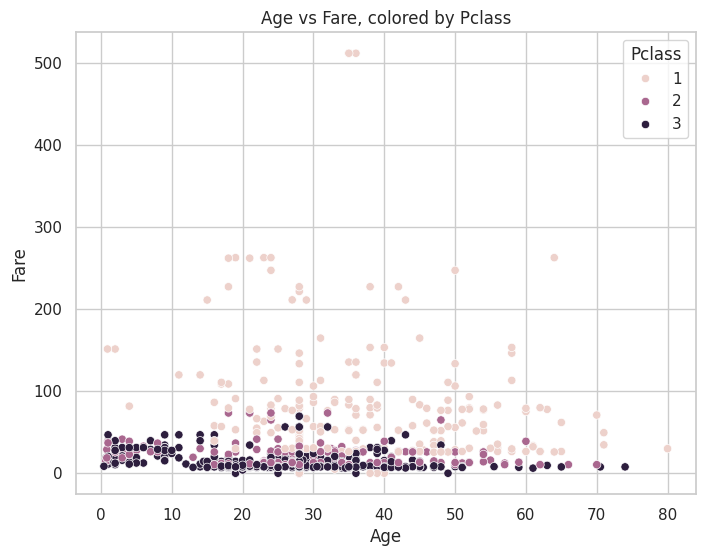

In [19]:
# TODO 1: Numerical vs Numerical.
# Create a scatterplot of Age (x) vs Fare (y), colored (hue) by Pclass.
# Hint: sns.scatterplot(x="Age", y="Fare", data=df, hue="Pclass")
plt.figure(figsize=(8, 6))
sns.scatterplot(x="Age", y="Fare", data=df, hue="Pclass")
plt.title("Age vs Fare, colored by Pclass")
plt.show()

**Numerical vs Categorical**

**Fare by Pclass**

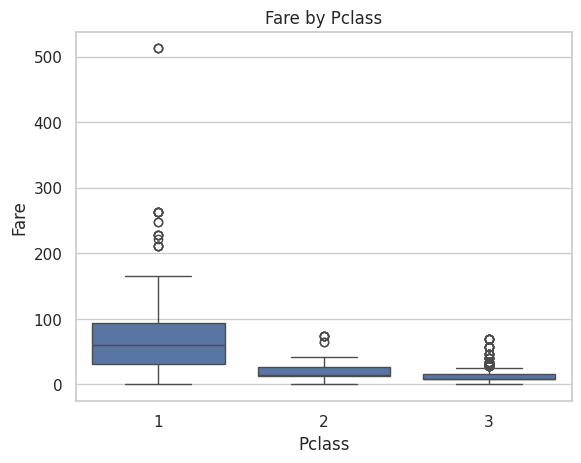

In [20]:

# TODO 2: Numerical vs Categorical.
# Create a boxplot of Fare by Pclass, and a separate boxplot of Age by
# Survived. Hint: sns.boxplot(x=..., y=..., data=df)
sns.boxplot(x="Pclass", y="Fare", data=df)
plt.title("Fare by Pclass")
plt.show()

**Age by survived**

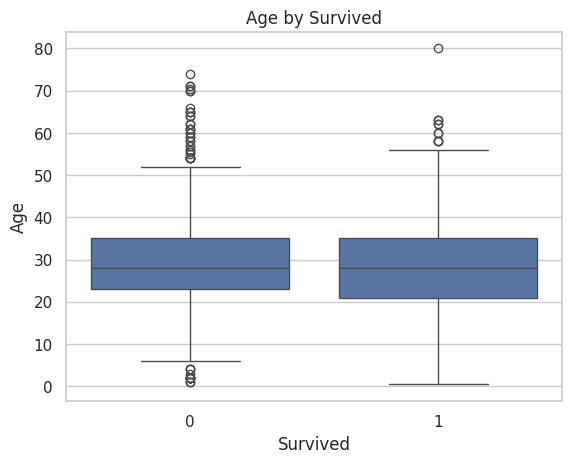

In [21]:
sns.boxplot(x="Survived", y="Age", data=df)
plt.title("Age by Survived")
plt.show()

**Categorical vs Categorical**

**Pclass grouped by Survived**

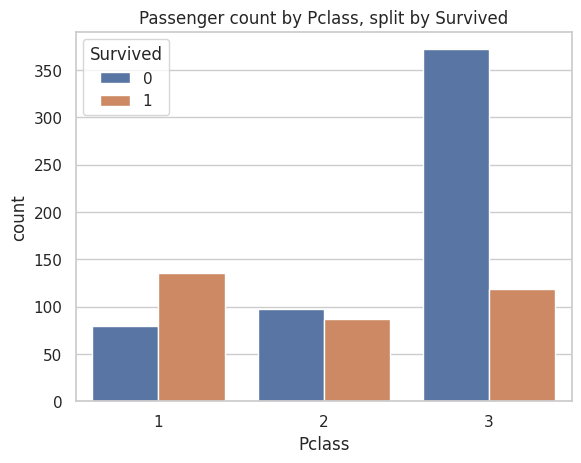

In [22]:
# TODO 3: Categorical vs Categorical.
# Create a countplot of Pclass with hue="Survived", and a countplot of
# Embarked with hue="Sex". Hint: sns.countplot(x=..., hue=..., data=df)

sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Passenger count by Pclass, split by Survived")
plt.show()

**Embarked grouped by Sex**

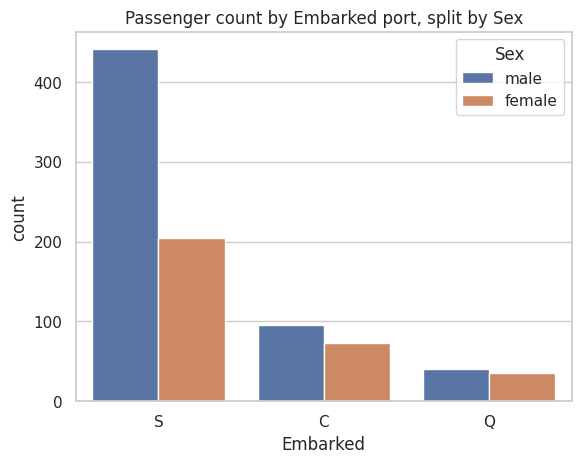

In [23]:
sns.countplot(x="Embarked", hue="Sex", data=df)
plt.title("Passenger count by Embarked port, split by Sex")
plt.show()


****Your bivariate findings, in your own words:** does `Fare` changewith `Pclass`? Do younger passengers look more likely to have survived?Does `Embarked` relate to `Sex` or survival in any visible way?**

Fare rises clearly with class; 1st class has the highest fares and widest spread, 3rd class is low and tightly clustered. Age vs Survived shows only a small difference; survivors skew slightly younger, but it's minor compared to Fare/Pclass. Embarked vs Sex: S skews more male overall, C is more balanced likely reflecting class mix at each port rather than the port itself.

**Step 5: Multivariate Analysis (your work)**

**Pair plot**

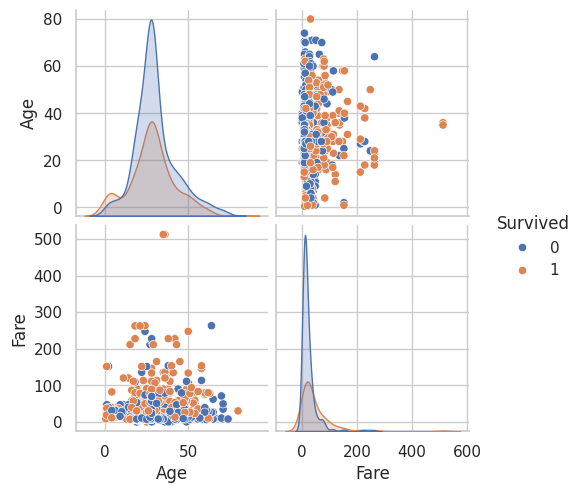

In [24]:
# TODO 1: Pair plot.
# Build a pairplot across ["Age", "Fare", "Survived"], with hue="Survived".
# Hint: sns.pairplot(df[[...]], hue="Survived", diag_kind="kde")
sns.pairplot(df[["Age", "Fare", "Survived"]], hue="Survived", diag_kind="kde")
plt.show()

**FacetGrid**

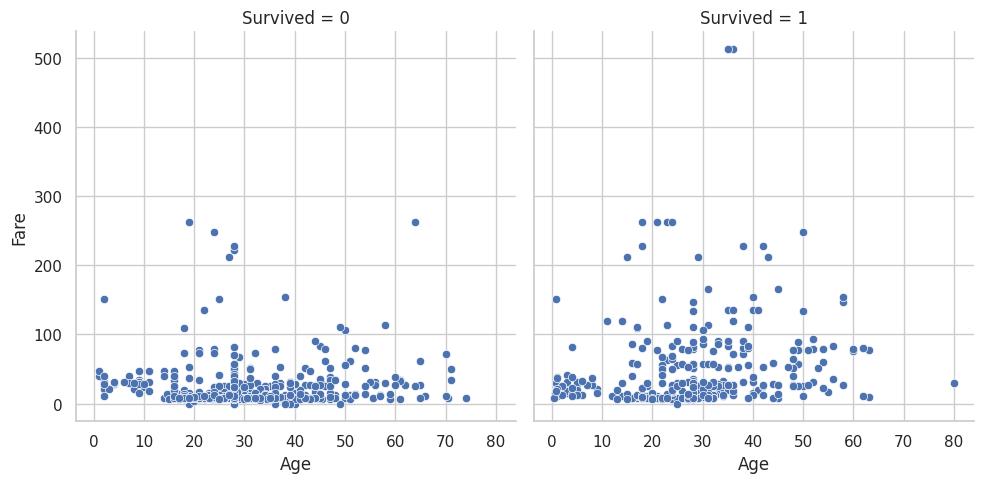

In [25]:
# TODO 2: FacetGrid.
# Build a FacetGrid with col="Survived", and map a scatterplot of Age vs
# Fare onto it. Hint: sns.FacetGrid(df, col="Survived") then g.map_dataframe(...)
g = sns.FacetGrid(df, col="Survived", height=5)
g.map_dataframe(sns.scatterplot, x="Age", y="Fare")
plt.show()

**Corelation heatmap**

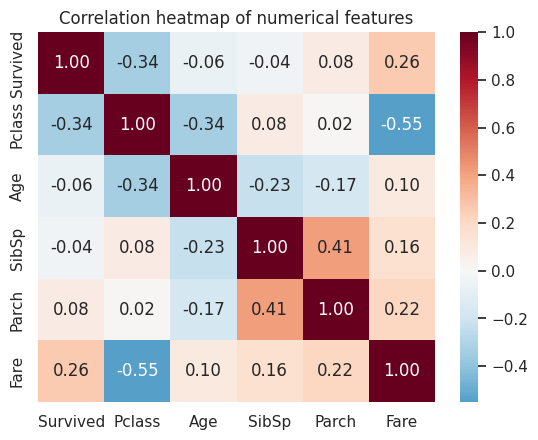

In [26]:
# TODO 3: Correlation heatmap.
# Pick a list of numerical columns (include Survived, Pclass, Age, SibSp,
# Parch, Fare, and the Has_Cabin flag from Step 2), compute df[cols].corr(),
# and plot it with sns.heatmap(..., annot=True, cmap="RdBu_r", center=0).
corr_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
corr_matrix = df[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlation heatmap of numerical features")
plt.show()


****Your multivariate findings, in your own words:** which feature looks**
**most strongly correlated with `Survived`? Does the FacetGrid show a****different Age-vs-Fare pattern for survivors than non-survivors?**

Pclass and Fare show the clearest link to Survived (-0.34 and +0.26), and since they are strongly correlated with each other too, they are basically pointing at the same thing wealth/class. Age doesn't correlate much (-0.06). The FacetGrid confirms this: the two panels look almost identical in age spread, but the survivors' panel has  more high-fare points.

**Step 6: Target Variable Analysis (your work)**

**Check balance**

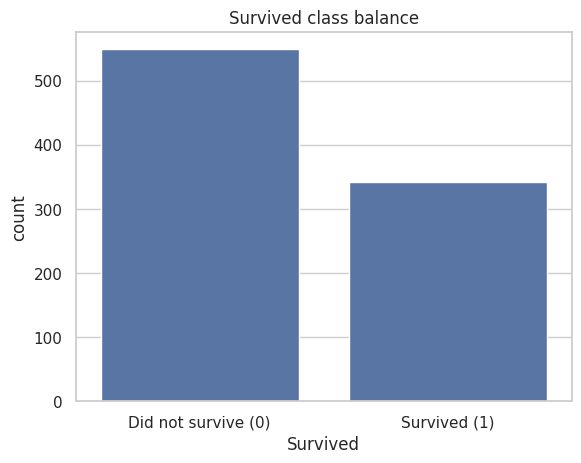

Overall survival rate: 0.3838383838383838
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [27]:
# TODO 1: Class balance.
# Plot a countplot of Survived, and print the overall survival rate
# (df["Survived"].mean()) plus the normalized value_counts().
sns.countplot(x="Survived", data=df)
plt.title("Survived class balance")
plt.xticks([0, 1], ["Did not survive (0)", "Survived (1)"])
plt.show()

print("Overall survival rate:", df["Survived"].mean())
print(df["Survived"].value_counts(normalize=True))

**survival rate by feature**

**Survival rate by Sex, Pclass, Embarked**

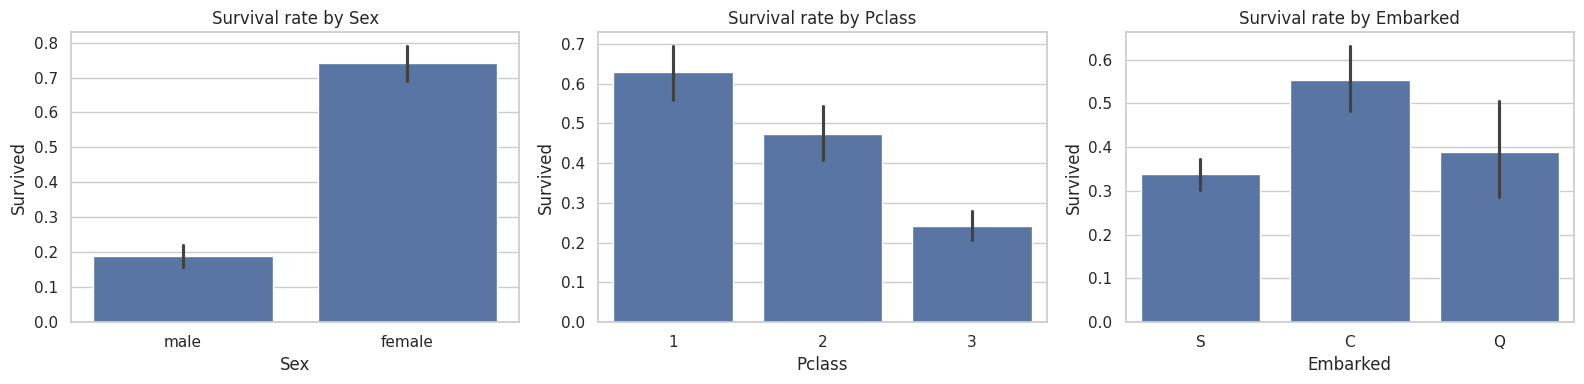

In [28]:
# TODO 2: Survival rate by feature.
# Build bar plots of survival rate (y="Survived") by Sex, by Pclass, and
# by Embarked. Hint: sns.barplot(x=..., y="Survived", data=df)
# For an Age view, first bin Age into groups with pd.cut(), e.g.
# bins=[0, 12, 18, 35, 60, 100], then bar-plot survival rate by that bin.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.barplot(x="Sex", y="Survived", data=df, ax=axes[0])
axes[0].set_title("Survival rate by Sex")

sns.barplot(x="Pclass", y="Survived", data=df, ax=axes[1])
axes[1].set_title("Survival rate by Pclass")

sns.barplot(x="Embarked", y="Survived", data=df, ax=axes[2])
axes[2].set_title("Survival rate by Embarked")

plt.tight_layout()
plt.show()

**Survival rate by Age group**

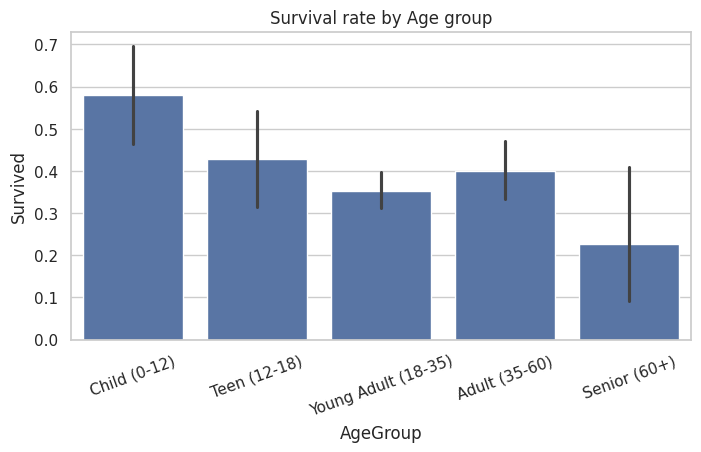

In [29]:
age_bins = [0, 12, 18, 35, 60, 100]
age_labels = ["Child (0-12)", "Teen (12-18)", "Young Adult (18-35)", "Adult (35-60)", "Senior (60+)"]
df["AgeGroup"] = pd.cut(df["Age"], bins=age_bins, labels=age_labels)

plt.figure(figsize=(8, 4))
sns.barplot(x="AgeGroup", y="Survived", data=df)
plt.title("Survival rate by Age group")
plt.xticks(rotation=20)
plt.show()

**cross-tabulation**

In [30]:
# TODO 3: Cross-tabulations.
# Build pd.crosstab(df["Pclass"], df["Survived"], normalize="index") and
# pd.crosstab(df["Sex"], df["Survived"], normalize="index") to see the
# exact survival rate per group as a table, not just a chart.
print(pd.crosstab(df["Pclass"], df["Survived"], normalize="index"))
print(pd.crosstab(df["Sex"], df["Survived"], normalize="index"))

Survived         0         1
Pclass                      
1         0.370370  0.629630
2         0.527174  0.472826
3         0.757637  0.242363
Survived         0         1
Sex                         
female    0.257962  0.742038
male      0.811092  0.188908



****Your target-variable findings, in your own words:** which singlefeature looks like the strongest driver of survival in this dataset?Does combining two features (for example Sex and Pclass together) tellyou more than looking at either one alone?**

Sex is the biggest factor by far  most women survived, while most men did not. Pclass matters too, with survival dropping steadily from 1st class down to 3rd. Combining the two shows even more: women in 1st/2nd class survived almost always, while men in 3rd class almost never did. So it's really both together, not just one on its own.

## Conclusion 


**Write a short (3-5 sentence) closing summary of your EDA report. Pulltogether what Steps 1-6 showed: what shape the data was in, how youhandled the missing values and outliers, and above all, what theclearest pattern is that explains who survived on the Titanic.**

The dataset started with three columns having missing values; Age, Cabin, and Embarked.which I handled by imputing Age and Embarked and flagging Cabin rather than guessing at it, and I checked Fare and Age for outliers using the IQR and Z-score methods, keeping the extreme fares since they're real 1st-class prices, not errors. Across the univariate, bivariate, and multivariate steps, Age consistently showed only a weak relationship with anything else, while Fare and Pclass kept showing up as strongly linked to each other and to survival. The clearest pattern in the whole dataset is that Sex and Pclass together explain survival far better than either alone , women in 1st/2nd class survived almost always, while men in 3rd class almost never did. Overall, this confirms the "women and children first" story, but shows it was heavily shaped by class and wealth rather than being an equal rule for everyone.